# Mini-Project: MiniGrid

## Overview

In this mini-project, you will develop an agent that navigates a family of [MiniGrid](https://minigrid.farama.org/) environments. MiniGrid is a lightweight grid-world benchmark widely used in reinforcement learning research.

Your agent must observe the environment and select actions to reach the goal as efficiently as possible. You may use any method — heuristic, classical planning, or learned (e.g., RL or imitation learning).

## Development

### Setup

Project dependencies are listed in `environment.yml`. Refer to Assignment 1 for environment setup instructions.

### External Computational Resources

It is useful to have access to computing resources to run your code and train your agent.

- [Google Colaboratory](https://colab.research.google.com/)

- [The School of Computing Compute Cluster](https://dochub.comp.nus.edu.sg/cf/guides/compute-cluster/start)

You can also run your code on your own computer. However, keep in mind that your computer may not have as much processing power or memory as the other options, so your code may run more slowly and you will take more time to complete the mini-project.


## Submission

Develop an agent that solves a family of MiniGrid environments as effectively as possible.

Implement the `Agent` class (see [Agent](#Agent)) with your logic.

### Submission Details

#### Agent

Submit your `Agent` class to Coursemology. There are **6 tasks**: one warm-up and five main tasks. Each task corresponds to one MiniGrid environment. You may use a single agent across all tasks or provide a different one per task.

You do not need to solve all tasks to receive full marks — see the grading scheme below.

#### Supplementary Files

Upload **all** code and files used to build your agent — training scripts, dataset generation scripts, generated datasets, and model checkpoints. These are required for plagiarism detection and to confirm originality.

<b style="color:red">Note: Failure to provide supplementary files will result in zero marks for the project.</b>

### Coursemology Constraints

- **Time limit:** 30 seconds per task.
- **Time limit per episode:** 3 seconds.
- **Number of episodes per task:** 10.
- **Memory:** 1.5 GB maximum.
- **Upload size:** 2 MB maximum.
- **Compute:** CPU only (no GPU). Assume a single core — avoid multithreaded or multiprocess solutions.
- **Available libraries:** See `environment.yml`. Do **not** rely on any libraries outside those listed.

### Submission Process

Submit your agent on [Coursemology](https://coursemology.org/courses/3233/assessments/90610).

1. On Coursemology, navigate to your mini-project task and click **Attempt**.
2. Paste your `Agent` class (and any helper code or `get_model()` if applicable) into the code editor.
3. Click **Check Answer** to run the grader and view your score. You may check as many times as you like before the deadline.
4. Once satisfied, click **Finalise all answers**. **Do this only once** — it cannot be undone.

<span style="color: red">**Note:** One submission per group only. If multiple submissions are received from the same group, the last one will be graded. Late submissions incur a penalty for the entire group.</span>

#### Notes

- Press **Finalise Submission** only after completing all tasks.
- The mini-project is **not** auto-submitted at the deadline.

### Grading Scheme

The project is worth **20 marks** in total:

| Component | Marks | Details |
|-----------|-------|---------|
| Performance | 12 | Agent success rate across submitted tasks |
| Report | 8 | Written analysis |

#### Performance (12 marks)

Each of the 6 tasks is worth up to **3 marks**, awarded proportionally to success rate up to 80% and rounded to the nearest 0.5:

$$\text{task marks} = \text{round}_{0.5}\!\left(\min\!\left(\frac{\text{success rate} - \text{min success rate}}{80\% - \text{min success rate}},\ 1\right) \times 3\right)$$

Minimum success rate is 0% unless otherwise stated — see [Environments](#Environments).

Performance marks are the sum across all attempted tasks, **capped at 12**.

| Tasks at ≥ 80% success | Performance marks |
|------------------------|-------------------|
| Warm-up only | 3 |
| Warm-up + 2 main | 9 |
| Warm-up + 3 main | 12 *(full)* |
| All 6 tasks | 12 *(capped)* |

**Strategy:** The warm-up (Empty 8×8) is nearly trivial. Solving 3 of the 5 main tasks at ≥ 80% success is sufficient for full performance marks. Partial success across more tasks can also accumulate toward the cap.

#### Report (8 marks)

Write a report covering the four sections below, each equally weighted.

| Section | Criteria |
|---------|----------|
| Environment analysis | Identifies the key challenges of each attempted environment (e.g., partial observability, exploration, memory, dynamic elements). Goes beyond surface-level description. |
| Techniques | Clearly describes the method(s) used — algorithm, architecture, and training procedure. Justifies design choices with reference to the identified environment challenges. |
| Results | Reports empirical success rates per environment. Includes sufficient detail (e.g., training curves, ablations, or comparisons) to support the claims. |
| Discussion | Reflects on what worked and what did not. Proposes concrete, well-reasoned improvements or alternative approaches. |

**Requirements:**

- Max 5 pages, A4, 12 pt font, 2.5 cm margins on all sides.
- Figures and tables are permitted and do not count toward the page limit.

The report is worth **8 marks**, split equally across all four sections (**2 marks each**).

Each section is graded holistically on depth and quality:

- **2 marks** — Thorough, well-argued, and precise. Demonstrates clear understanding and genuine insight.
- **1 mark** — Partially meets the criteria. Some important aspects are addressed, but the analysis is shallow, vague, or incomplete.
- **0 marks** — Missing, off-topic, or below the minimum standard.

Sections are graded independently, so strength in one can offset a weaker section.


## MiniGrid

### Overview

[MiniGrid](https://minigrid.farama.org/) is a minimalistic grid-world framework for reinforcement learning research. Each environment is a 2-D grid of cells. Rather than observing the full map, the agent sees only a small egocentric 7×7 window in front of it, which makes these environments challenging for both classical and learning-based methods.

**Key concepts:**
- **Observation:** A `dict` with three keys:
  - `"image"`: shape `(7, 7, 3)`, dtype `uint8`. Each cell is encoded as `(object_idx, color_idx, state)`. Useful object indices: `1`=empty, `2`=wall, `4`=door, `5`=key, `8`=goal, `10`=agent. Full mapping: [`minigrid/core/constants.py`](https://github.com/Farama-Foundation/Minigrid/blob/master/minigrid/core/constants.py).
  - `"direction"`: `int` in `{0, 1, 2, 3}` — the agent's facing direction: `0`=right, `1`=down, `2`=left, `3`=up.
  - `"mission"`: `str` — natural-language description of the task goal.
- **Actions:** `Discrete(7)` — `0` turn left, `1` turn right, `2` move forward, `3` pick up, `4` drop, `5` toggle, `6` done.
- **Reward:** `1 − 0.9 × (step_count / max_steps)` on success; `0` otherwise. Rewards decrease with time, incentivising efficient navigation.
- **Partial observability:** The agent sees only a 7×7 forward-facing cone — it cannot see behind walls, behind itself, or beyond its field of view.

### Resources

- [MiniGrid Documentation](https://minigrid.farama.org/)
- [MiniGrid GitHub Repository](https://github.com/Farama-Foundation/Minigrid)
- [Gymnasium Documentation](https://gymnasium.farama.org/)


### Environments

There are six environments in total: one warm-up and five main tasks.

| # | Name | Environment ID | Description |
|---|------|----------------|-------------|
| 1 | [Empty](https://minigrid.farama.org/environments/minigrid/EmptyEnv/) | `MiniGrid-Empty-8x8-v0` | **(Warm-up)** An open 8×8 grid with no obstacles. Navigate to the goal square. |
| 2 | [Door Key](https://minigrid.farama.org/environments/minigrid/DoorKeyEnv/) | `MiniGrid-DoorKey-8x8-v0` | The agent must pick up a key, unlock a door, and navigate through to reach the goal. |
| 3 | [Four Rooms](https://minigrid.farama.org/environments/minigrid/FourRoomsEnv/) | `MiniGrid-FourRooms-v0` | Four interconnected rooms with narrow openings. The goal position varies each episode. |
| 4 | [Dynamic Obstacles](https://minigrid.farama.org/environments/minigrid/DynamicObstaclesEnv/) | `MiniGrid-Dynamic-Obstacles-6x6-v0` | A compact grid where obstacles move each step. Colliding with a moving obstacle ends the episode. |
| 5 | [Lava Gap](https://minigrid.farama.org/environments/minigrid/LavaGapEnv/) | `MiniGrid-LavaGapS7-v0` | The agent must navigate across a lava wall through a narrow gap to reach the goal. Stepping on lava ends the episode immediately. |
| 6 | [Memory](https://minigrid.farama.org/environments/minigrid/MemoryEnv/) | `MiniGrid-MemoryS13Random-v0` | The agent must remember a cue from earlier in the episode to choose the correct path. **Note:** The minimum success rate for this environment is 50% (random chance), unlike the other environments where the minimum is 0%. |

In [2]:
import torch
device = "gpu" if torch.cuda.is_available() else "cpu"
print(device)

cpu


In [3]:
ENVS = {
    1: "MiniGrid-Empty-8x8-v0", # warmup environment
    2: "MiniGrid-DoorKey-8x8-v0",
    3: "MiniGrid-FourRooms-v0",
    4: "MiniGrid-Dynamic-Obstacles-6x6-v0",
    5: "MiniGrid-LavaGapS7-v0",
    6: "MiniGrid-MemoryS13Random-v0",
}

The cell below visualises each environment.


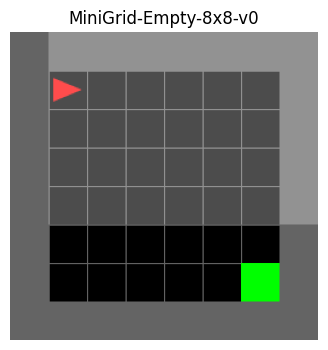

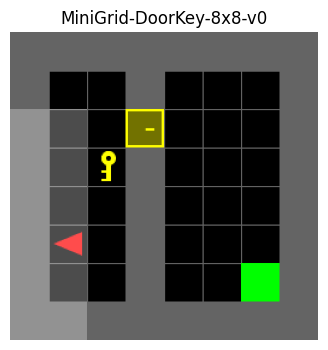

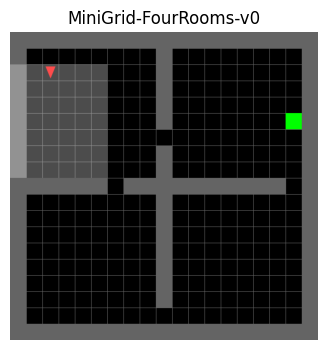

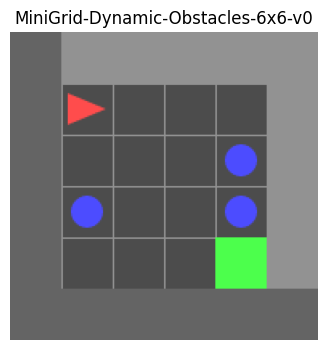

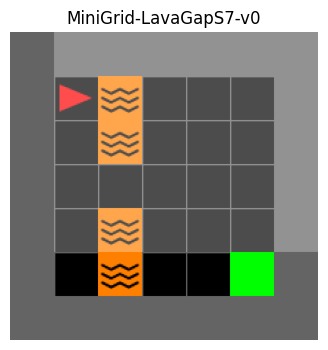

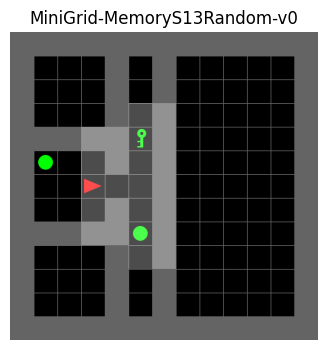

In [4]:
from utils import make_env, visualize_env

for _, env_name in ENVS.items():
    env = make_env(env_name)
    visualize_env(env, label=env_name)
    env.close()


## Agent

Implement the `Agent` class below. The grader instantiates it **once per task** as:

```python
agent = Agent(obs_space=env.observation_space, action_space=env.action_space)
```

At the start of each episode, `agent.reset()` is called once before the first `agent.act(obs)` call. Use `reset()` to clear any internal state maintained across steps (e.g., LSTM hidden states, step counters, episode memory).

You may use any approach: rule-based logic, a pre-trained neural network, a planning algorithm, etc. If your agent loads trained weights, embed them via `get_model()` (see [Submitting your Agent to Coursemology](#Submitting-your-Agent-to-Coursemology)).

**Starting points:** if you are unsure where to begin, consider training a CNN or MLP policy end-to-end with PPO or DQN on the `obs["image"]` array.


In [ ]:
class Agent:
    """Agent template

    This class is the single public interface that Coursemology will import and
    interact with when evaluating your submission. You should extend the
    internals (add helper classes / functions in other files if you wish) but
    MUST preserve:

    1. The class name: Agent
    2. The public method: act(self, obs) -> int
    3. The public method: reset(self)

    You may add __init__ parameters (with defaults) if needed for your own
    development, but the grader will only instantiate Agent() with:
    - obs_space = env.observation_space
    - action_space = env.action_space
    """

    def __init__(self, obs_space, action_space):
        """Initialize your agent.

        Put all one-time setup here (e.g., loading ML model weights).
        """
        self.obs_space = obs_space
        self.action_space = action_space
        
        self.WALL_IDX = 2
        self.GOAL_IDX = 8
        
        self.ACTION_LEFT = 0
        self.ACTION_RIGHT = 1
        self.ACTION_FORWARD = 2
        
        self.reset()

    def reset(self):
        """Reset any per-episode internal state.

        Called by the grader once at the start of every episode, before the
        first act() call. Implement this if your agent maintains state across
        steps (e.g., LSTM hidden states, step counters, visited-cell maps).
        """
        self.step_count = 0
        self.last_turn = self.ACTION_FORWARD
        
    def _agent_local_pos(self, obs):
        image = obs["image"]
        ego_view_width, ego_view_height = image.shape[:2]
        
        agent_x = ego_view_width // 2
        agent_y = ego_view_height - 1
        
        return agent_x, agent_y
    
    def _find_goal(self, obs):
        obj = obs["image"][:, :, 0]
        goal_pos = np.argwhere(obj == self.GOAL_IDX)
        
        # Goal not in image
        if len(goal_pos) == 0:
            return None
        
        # Return the first goal since Empty has 1 goal only
        return tuple(goal_pos[0])
    
    def _cell_is_wall(self, obj, x, y):
        return obj[x, y] == self.WALL_IDX
    
    def _choose_turn_when_blocked(self, obs):
        obj = obs["image"][:, :, 0]
        agent_x, agent_y = self._agent_local_pos(obs)
        
        left_x, left_y = agent_x - 1, agent_y
        right_x, right_y = agent_x + 1, agent_y
        
        left_blocked = self._cell_is_wall(obj, left_x, left_y)
        right_blocked = self._cell_is_wall(obj, right_x, right_y)
        
        if left_blocked and not right_blocked:
            return self.ACTION_RIGHT
        
        if right_blocked and not left_blocked:
            return self.ACTION_LEFT
        
        return self.ACTION_RIGHT
    
    def _front_is_blocked(self, obs):
        obj = obs["image"][:, :, 0]
        agent_x, agent_y = self._agent_local_pos(obs)
        
        front_x = agent_x
        front_y = agent_y - 1
        
        return obj[front_x, front_y] == self.WALL_IDX
    
    def _action_toward_goal(self, obs, goal_pos):
        goal_x, goal_y = goal_pos
        agent_x, agent_y = self._agent_local_pos(obs)
        
        if goal_x < agent_x:
            return self.ACTION_LEFT
        if goal_x > agent_x:
            return self.ACTION_RIGHT
        
        return self._exploration_action(obs)
    
    def _next_turn(self):
        if self.last_turn == self.ACTION_LEFT:
            self.last_turn = self.ACTION_RIGHT
        else:
            self.last_turn = self.ACTION_LEFT
        return self.last_turn
    
    def _exploration_action(self, obs):
        if self._front_is_blocked(obs):
            return self._choose_turn_when_blocked(obs)
        return self.ACTION_FORWARD

    def act(self, obs):
        """Return the next action given the current observation.

        Parameters
        ----------
        obs : dict
            A dict with keys:
            - ``"image"``: numpy array of shape ``(7, 7, 3)``, dtype uint8 —
              the agent's partial field-of-view encoded as (object, colour, state).
            - ``"direction"``: int in ``{0, 1, 2, 3}`` — the agent's facing direction
              (0=right, 1=down, 2=left, 3=up).
            - ``"mission"``: str — natural-language task description.

        Returns
        -------
        int
            An integer action in ``{0, …, 6}``:
            0=turn left, 1=turn right, 2=move forward,
            3=pick up, 4=drop, 5=toggle, 6=done.
        """
        # Placeholder: agent that chooses a random valid action each step
        self.step_count += 1
        
        goal_pos = self._find_goal(obs)                                                                                           
        agent_pos = self._agent_local_pos(obs)                                                                                    
        blocked = self._front_is_blocked(obs)                                                                                     
                                                                                                                                    
        print(                                                                                                                    
            f"step={self.step_count}, goal_pos={goal_pos}, agent_pos={agent_pos}, "                                               
            f"front_blocked={blocked}, direction={obs['direction']}"                                                              
        )
        
        goal_pos = self._find_goal(obs)
        if goal_pos is not None:
            return self._action_toward_goal(obs, goal_pos)
        
        return self._exploration_action(obs)

In [15]:
import importlib
import multienv_task_agent

importlib.reload(multienv_task_agent)
Agent = multienv_task_agent.Agent

### Evaluating your Agent

The cells below let you evaluate your `Agent` locally:

1. **Single episode** — runs one episode with optional frame-by-frame visualisation. Useful for debugging behaviour.
2. **Multi-episode** — runs N episodes and reports success rate and mean reward, mirroring the grader.

For both cells, change the index in `ENVS[1]` to select a different environment (e.g., `ENVS[2]`). The environment's built-in `max_steps` limit is used, matching the grader.


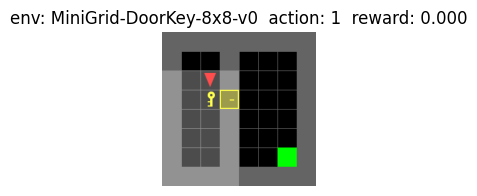

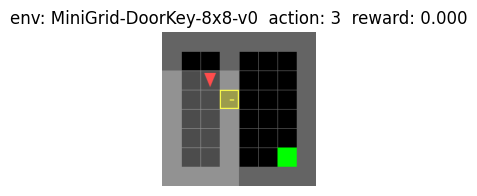

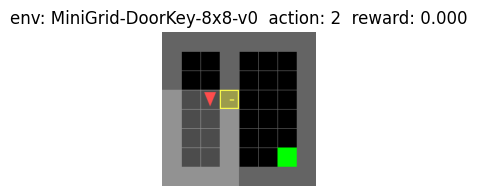

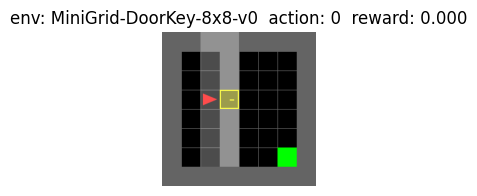

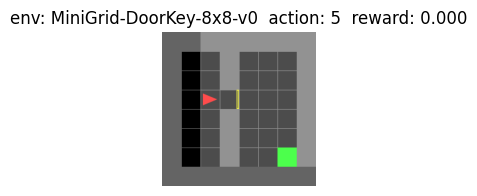

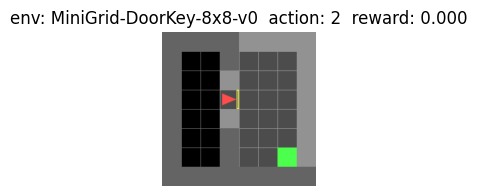

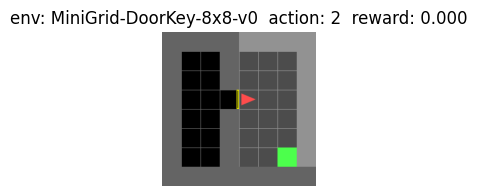

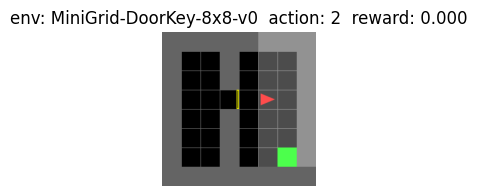

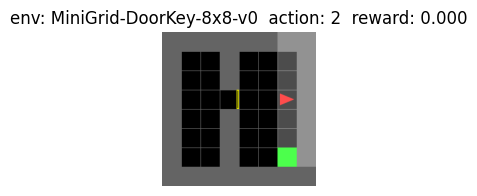

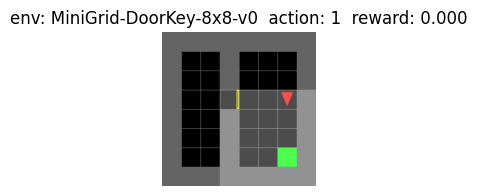

Total reward: 0.982
Success: True


In [16]:
from utils import make_env, visualize_frame

# --- Single-episode evaluation with visualisation ---
env_id = ENVS[2]      # change index to pick environment
visualize = True      # set to False to skip frame rendering
visualize_number = 10  # number of frames to visualize (set to None to visualize all frames)

env = make_env(env_id)
agent = Agent(obs_space=env.observation_space, action_space=env.action_space)

obs, _ = env.reset()
agent.reset()  # reset agent state at the start of each episode

total_reward = 0.0
success = False
done = False
step = 0
while not done:
    action = agent.act(obs)
    obs, reward, terminated, truncated, info = env.step(action)
    total_reward += float(reward)
    if visualize and (visualize_number is None or step < visualize_number):
        frame = env.render()
        visualize_frame(frame, f"env: {env_id}  action: {action}  reward: {reward:.3f}", size="small")
    if terminated:
        success = float(reward) > 0  # reward > 0 → goal reached; ≤ 0 → failure (e.g. obstacle collision)
        done = True
    elif truncated:
        done = True
    step += 1

env.close()
print(f"Total reward: {total_reward:.3f}")
print(f"Success: {success}")


In [17]:
from utils import make_env
import numpy as np

# --- Multi-episode evaluation (mirrors the grader) ---
env_id = ENVS[6]   # change index to pick environment
n_episodes = 100    # number of episodes to average over

env = make_env(env_id)
agent = Agent(obs_space=env.observation_space, action_space=env.action_space)

successes = []
rewards = []

for ep in range(n_episodes):
    obs, _ = env.reset()
    agent.reset()  # reset agent state at the start of each episode

    total_reward = 0.0
    success = False
    done = False
    while not done:
        action = agent.act(obs)
        obs, reward, terminated, truncated, info = env.step(action)
        total_reward += float(reward)
        if terminated:
            success = float(reward) > 0
            done = True
        elif truncated:
            done = True
    successes.append(success)
    rewards.append(total_reward)

env.close()

success_rate = np.mean(successes) * 100
mean_reward  = np.mean(rewards)
std_reward   = np.std(rewards)
print(f"Environment  : {env_id}")
print(f"Episodes     : {n_episodes}")
print(f"Success rate : {success_rate:.1f}%")
print(f"Mean reward  : {mean_reward:.4f} ± {std_reward:.4f}")


Environment  : MiniGrid-MemoryS13Random-v0
Episodes     : 100
Success rate : 100.0%
Mean reward  : 0.9877 ± 0.0036


### Submitting your Agent to Coursemology

> **Note:** This section is only relevant if your agent uses a trained PyTorch model. If your agent is purely rule-based and loads no external weights, skip this section.

Use the cell below to generate a `get_model()` function that embeds your trained model's weights as a base64 blob directly in the source code, making your submission fully self-contained.

**Steps:**

1. Replace `torch.nn.Linear(10, 5)` with your actual trained model instance.
2. Run the cell to print the generated `get_model()` function.
3. In your Coursemology submission, paste:
   - your `Agent` class,
   - any helper classes or functions it depends on, and
   - the generated `get_model()` function.
4. Inside `Agent.__init__`, call `get_model()` to load the weights.

If you have multiple models, call `generate_torch_loader_snippet` once per model.

If `prefer="state_dict"` fails (e.g., because the model class cannot be re-imported inside Coursemology), switch to `prefer="pickle"`.


In [ ]:
import torch
from utils import generate_torch_loader_snippet

# from pathlib import Path
# import torch
# from src.rl_multitask.config import TrainConfig
# from src.rl_multitask.model import MultiTaskNavActorCritic
# from utils import generate_torch_loader_snippet
# ckpt_path = Path("src/minigrid_nav/policy_bundle.pt.xz")
# payload = torch.load(ckpt_path, map_location="cpu", weights_only=False)
# config = TrainConfig(**payload["config"])
# model = MultiTaskNavActorCritic(config)
# model.load_state_dict(payload["model_state"])
# model.eval()
import io
import lzma
import torch
from pathlib import Path

from src.rl_multitask.config import TrainConfig
from src.rl_multitask.model import MultiTaskNavActorCritic

ckpt_path = Path("src/minigrid_nav/policy_bundle.pt.xz")

with lzma.open(ckpt_path, "rb") as f:
    bundle = torch.load(io.BytesIO(f.read()), map_location="cpu", weights_only=False)

payload = bundle["base"]  # or bundle["doorkey"]

config = TrainConfig(**payload["config"])
model = MultiTaskNavActorCritic(config)
model.load_state_dict(payload["model_state"])
model.eval()

# Generate and print the code snippet for loading the model using state_dict
print(generate_torch_loader_snippet(model, prefer="state_dict"))

# If the above does not work, you can use the following method:
# Generate and print the code snippet for loading the model using pickle
# print(generate_torch_loader_snippet(model, prefer="pickle"))

#### Debugging your Agent in Coursemology

To help you debug your code, **Task 1** displays the actual error messages generated by your submission. Use this task as a sanity check to verify that your agent is functioning as expected.

We have also set up a dedicated dummy assignment called **"Coursemology"**, which you can use to check the execution time of your code within the Coursemology environment, as well as the libraries available to you.